In [3]:
!pip install mp_api

# Fetching the Data


In [ ]:
from mp_api.client import MPRester
import json
from emmet.core.summary import HasProps
import pandas as pd

"This script retrieves data for all perovskite materials with the formula ABC3 from the Materials Project database and saves it to a JSON file. It then converts the JSON data into a pandas DataFrame for further analysis."


with MPRester("NoQqkP6G1g6xkxgUb7aClJ69vQM2CZNA") as mpr:
    # Retrieve the summary data for the material
    material_data = mpr.materials.summary.search(
        formula="ABC3",
    )

    # Save the data to a JSON file
    all_data = [entry.dict() for entry in material_data]
    with open("ABC3.json", "w") as json_file:
        json.dump(all_data, json_file, indent=4)

print("Data for all perovskites has been saved to perovskites.json")

# Convert the JSON file into a pandas DataFrame

with open("ABC3.json", "r") as json_file:
    data = json.load(json_file)

df_ABC3 = pd.json_normalize(data)

/Users/dominikgotz/Documents/Digichem/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving SummaryDoc documents: 100%|██████████| 4700/4700 [00:05<00:00, 860.22it/s]


Data for all perovskites has been saved to perovskites.json


In [ ]:
# FIlter out the theoretical values and entries with a band gap of 0
df_ABC3 = df_ABC3[(df_ABC3["theoretical"] == False) & (df_ABC3["band_gap"] > 0)]
# Drop Crystal structures with the same formula and symmetry
df_ABC3_filtered = df_ABC3.drop_duplicates(
    subset=["formula_pretty", "symmetry.crystal_system"]
)

print("Database has been converted to a pandas DataFrame and saved to perovskites.csv")
df_ABC3_filtered

Database has been converted to a pandas DataFrame and saved to perovskites.csv


,nsites,elements,nelements,formula_pretty,formula_anonymous,chemsys,volume,density,density_atomic,property_name,...,dos.elemental.Na.f.-1.task_id,dos.elemental.Na.f.-1.band_gap,dos.elemental.Na.f.-1.cbm,dos.elemental.Na.f.-1.vbm,dos.elemental.Na.f.-1.efermi,dos.elemental.Na.f.-1.spin_polarization,bandstructure.hinuma.equivalent_labels.latimer_munro.setyawan_curtarolo.l_{1},bandstructure.hinuma.equivalent_labels.latimer_munro.setyawan_curtarolo.l_{2},bandstructure.hinuma.equivalent_labels.latimer_munro.hinuma.l_{1},bandstructure.hinuma.equivalent_labels.latimer_munro.hinuma.l_{2}
14,20,"[Ag, Br, S]",3,Ag3SBr,ABC3,Ag-Br-S,484.805518,5.967646,24.240276,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,5,"[Ag, I, S]",3,Ag3SI,ABC3,Ag-I-S,121.855550,6.576090,24.371110,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,5,"[Ag, I, S]",3,Ag3SI,ABC3,Ag-I-S,125.720329,6.373934,25.144066,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,120,"[Ag, As, O]",3,AgAsO3,ABC3,Ag-As-O,1728.699515,5.320520,14.405829,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,20,"[Ag, Cl, O]",3,AgClO3,ABC3,Ag-Cl-O,307.063628,4.138469,15.353181,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4677,20,"[Br, Nb, Se]",3,NbSeBr3,ABC3,Br-Nb-Se,614.983064,4.445273,30.749153,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4678,20,"[Cl, Nb, Se]",3,NbSeCl3,ABC3,Cl-Nb-Se,537.955987,3.435256,26.897799,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4679,20,"[I, Nb, Se]",3,NbSeI3,ABC3,I-Nb-Se,728.473235,5.038375,36.423662,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4680,20,"[Br, Nb, Te]",3,NbTeBr3,ABC3,Br-Nb-Te,643.060997,4.753581,32.153050,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Now get the other perovskite structure A2BCX6
with MPRester("NoQqkP6G1g6xkxgUb7aClJ69vQM2CZNA") as mpr:
    # Retrieve the summary data for the material
    material_data = mpr.materials.summary.search(
        formula="A2BCX6",
    )

    # Save the data to a JSON file
    all_data = [entry.dict() for entry in material_data]
    with open("A2BCX6.json", "w") as json_file:
        json.dump(all_data, json_file, indent=4)

print("Data for all perovskites has been saved to perovskites.json")

# Convert the JSON file into a pandas DataFrame
# Load the JSON file
with open("A2BCX6.json", "r") as json_file:
    data = json.load(json_file)

df_A2BCX6 = pd.json_normalize(data)

Retrieving SummaryDoc documents: 100%|██████████| 4817/4817 [00:08<00:00, 546.32it/s]


Data for all perovskites has been saved to perovskites.json


In [10]:
# Optionally, save the DataFrame to a CSV file
df_A2BCX6 = df_A2BCX6[(df_A2BCX6["theoretical"] == False) & (df_A2BCX6["band_gap"] > 0)]
# filter for non-zero band gaps and experimental band_gap values
df_A2BCX6_filtered = df_A2BCX6.drop_duplicates(
    subset=["formula_pretty", "symmetry.crystal_system"]
)
df_A2BCX6_filtered

,nsites,elements,nelements,formula_pretty,formula_anonymous,chemsys,volume,density,density_atomic,property_name,...,dos.elemental.Tm.f.-1.cbm,dos.elemental.Tm.f.-1.vbm,dos.elemental.Tm.f.-1.efermi,dos.elemental.Tm.f.-1.spin_polarization,dos.elemental.Pt.f.-1.task_id,dos.elemental.Pt.f.-1.band_gap,dos.elemental.Pt.f.-1.cbm,dos.elemental.Pt.f.-1.vbm,dos.elemental.Pt.f.-1.efermi,dos.elemental.Pt.f.-1.spin_polarization
1,20,"[Ag, Bi, P, S]",4,AgBi(PS3)2,ABC2D6,Ag-Bi-P-S,457.332464,4.147866,22.866623,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20,"[Ag, Bi, P, Se]",4,AgBi(PSe3)2,ABC2D6,Ag-Bi-P-Se,566.712748,4.996192,28.335637,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60,"[Ag, F, Sb, Se]",4,AgSb(SeF3)2,ABC2D6,Ag-F-Sb-Se,1198.669208,4.168745,19.977820,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,40,"[Al, Cl, O, Sn]",4,Al2SnCl6O,ABC2D6,Al-Cl-O-Sn,1164.118551,2.290229,29.102964,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,40,"[Al, Cl, N, S]",4,AlS2NCl6,ABC2D6,Al-Cl-N-S,1178.882749,1.790779,29.472069,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,20,"[Ag, In, P, Se]",4,InAg(PSe3)2,ABC2D6,Ag-In-P-Se,545.540583,4.616861,27.277029,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4597,20,"[Cu, In, P, Se]",4,InCu(PSe3)2,ABC2D6,Cu-In-P-Se,504.009233,4.705246,25.200462,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4752,20,"[Al, F, K, Li]",4,K2LiAlF6,ABC2D6,Al-F-K-Li,243.026647,3.089898,12.151332,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4755,10,"[Al, F, K, Li]",4,K2LiAlF6,ABC2D6,Al-F-K-Li,126.978696,2.956904,12.697870,summary,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
df_unfiltered = pd.concat([df_ABC3, df_A2BCX6], axis=0, ignore_index=True)
df_unfiltered.to_csv("df_unfiltered.csv", index=False)
df_unfiltered = pd.read_csv("df_unfiltered.csv")
# Safe the dataframe that contaisn both perovskites, to not have to run the feth part over and over again it is read from the csv file

/var/folders/k8/4c7hpqw11gq276z_k941vshc0000gn/T/ipykernel_66273/3606008496.py:3: DtypeWarning: Columns (65,138,142,148,152,198,202,208,212,258,262,268,272,311,317,323,329,335,365,413,419,425,431,437,487,493,499,505,511,517,523,529,535,541,571,603,609,615,621,627,649,661,673,685,691,697,705,711,717,723,729,741,747,753,759,765,773,779,785,791,797,803,809,815,821,827,835,847,859,871,897,903,909,915,921,929,935,941,947,961,967,973,979,985,993,999,1005,1011,1017,1023,1029,1035,1060,1067,1086,1087,1089,1090,1091,1093,1096,1097,1099,1100,1102,1103,1104,1106,1109,1110,1111,1112,1115,1118,1119,1122,1128,1134,1138,1139,1141,1142,1143,1144,1145,1148,1149,1151,1152,1154,1155,1156,1157,1158,1161,1162,1164,1171,1190,1191,1193,1194,1195,1197,1200,1201,1203,1204,1206,1207,1208,1210,1213,1214,1215,1221,1227,1233,1263,1269,1275,1281,1301,1302,1303,1304,1305,1306,1307,1310,1312,1313,1314,1315,1316,1317,1318,1319,1322,1324,1325,1326,1330,1331,1340,1347,1349,1350,1351,1352,1353,1354,1355,1360,1361,1362,13

# Appending of Phsical Data

In [124]:
"Get all the important packages to extract the data from the data set"

import pandas as pd
from collections import Counter
import numpy as np
from rdkit.Chem import GetPeriodicTable
from mendeleev import element

from ase import Atoms
from dscribe.descriptors import SOAP
import numpy as np
import pandas as pd
import numpy as np
from pymatgen.core import Element
from mendeleev import element
import ast
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [125]:
elemental_abundance = {
    "Ac": 0.000000000055,
    "Ag": 0.075,
    "Al": 82300,
    "Ar": 3.5,
    "As": 1.8,
    "At": 0.000000000005,
    "Au": 0.004,
    "B": 10,
    "Ba": 425,
    "Be": 2.8,
    "Bi": 0.0085,
    "Br": 2.4,
    "C": 200,
    "Ca": 41500,
    "Cd": 0.15,
    "Ce": 66.5,
    "Cl": 145,
    "Co": 25,
    "Cr": 102,
    "Cs": 3,
    "Cu": 60,
    "Dy": 5.2,
    "Er": 3.5,
    "Eu": 2,
    "F": 585,
    "Fe": 56300,
    "Fr": 0.000000000005,
    "Ga": 19,
    "Gd": 6.2,
    "Ge": 1.5,
    "H": 1400,
    "He": 0.008,
    "Hf": 3.0,
    "Hg": 0.085,
    "Ho": 1.3,
    "I": 0.45,
    "In": 0.25,
    "Ir": 0.001,
    "K": 20900,
    "Kr": 0.0001,
    "La": 39,
    "Li": 20,
    "Lu": 0.8,
    "Mg": 23300,
    "Mn": 950,
    "Mo": 1.2,
    "N": 19,
    "Na": 23600,
    "Nb": 20,
    "Nd": 41.5,
    "Ne": 0.005,
    "Ni": 84,
    "Np": 0.00000000005,
    "O": 461000,
    "Os": 0.0015,
    "P": 1050,
    "Pa": 0.00000000005,
    "Pb": 14,
    "Pd": 0.015,
    "Pm": 0.00000000005,
    "Po": 0.00000000002,
    "Pr": 9.2,
    "Pt": 0.005,
    "Pu": 0.00000000005,
    "Ra": 0.0000009,
    "Rb": 90,
    "Re": 0.0007,
    "Rh": 0.001,
    "Rn": 0.0000000000004,
    "Ru": 0.001,
    "S": 350,
    "Sb": 0.2,
    "Sc": 22,
    "Se": 0.05,
    "Si": 282000,
    "Sm": 7.05,
    "Sn": 2.3,
    "Sr": 370,
    "Ta": 2.0,
    "Tb": 1.2,
    "Tc": 0.0000000005,
    "Te": 0.001,
    "Th": 9.6,
    "Ti": 5650,
    "Tl": 0.85,
    "Tm": 0.52,
    "U": 2.7,
    "V": 120,
    "W": 1.25,
    "Xe": 0.00003,
    "Y": 33,
    "Yb": 3.2,
    "Zn": 70,
    "Zr": 165,
}


def convert_string_to_list(element_string):
    """
    Converts a string representation of a list into an actual list.

    Parameters:
        elemnent_string (str): A string representation of a list, e.g., "['Ni', 'O', 'Sr', 'W']".
    Returns:
        Retuns a list of elements if the string is valid, otherwise returns an empty list.
    """

    try:
        return ast.literal_eval(element_string)
    except (SyntaxError, ValueError):
        return []  # Or handle errors as appropriate


# Define your abundance threshold
abundance_threshold = 10  # Example threshold in ppm


def is_abundant_perovskite(elements, abundance_data, threshold):
    """
    Checks if all elements in a list are above the abundance threshold.

    Args:
        elements (list): A list of element symbols (e.g., ['Ni', 'O', 'Sr', 'W']).
        abundance_data (dict): A dictionary of elemental abundances (e.g., {'Ni': 18.0, ...}).
        threshold (float): The minimum abundance threshold.

    Returns:
        bool: True if all elements are above the threshold, False otherwise.
    """
    for element in elements:
        if element in abundance_data and abundance_data[element] <= threshold:
            return False
        elif element not in abundance_data:
            print(
                f"Warning: Abundance data not found for element '{element}'. Assuming it's not abundant."
            )
            return False  # Or you could choose to handle missing data differently
    return True

In [126]:
"this part creates the dataframes wit hall the physcal properties that we need"

missing_fusion_heats = {
    "As": 24.44,  # kJ/mol
    "O": 0.44,
    "N": 0.72,
    "C": 117,
    "Ru": 38.59,
    "Tb": 10.15,
    "Gd": 10.05,
    "Dy": 11.06,
    "Eu": 9.21,
    "Ho": 17.0,
    "Er": 19.9,
    "Lu": 22,
    "Tm": 16.84,
}


def get_fusion_heat(element_symbol):
    """
    gets the fusion heat of an element using the mendeleev package.

    Parameters:
        elemnent_symbol (str):  element symbols, e.g., ['Ni', 'O', 'Sr', 'W'].
    Returns:
        Return the fusion heat of the element in kJ/mol if it is available, otherwise returns a value from the missing_fusion_heats dictionary.
    """
    elmt = element(element_symbol)
    if elmt.fusion_heat is None and element_symbol in missing_fusion_heats:
        return missing_fusion_heats[element_symbol]
    elif elmt.fusion_heat is None and element_symbol not in missing_fusion_heats:
        print(elmt.name, "is missing fusion heat value")
    else:
        return elmt.fusion_heat


missing_evaporation_heats = {
    "O": 6.82,  # kJ/mol
    "N": 5.58,
    "C": 715,
    "Ru": 619,
    "Tb": 391,
}

from mendeleev import element


def get_evaporation_heat(element_symbol):
    """
    Gets the evaporation heat of an element using the mendeleev package.

    Parameters:
        elemnent_symbol (str): element symbols, e.g., ['Ni', 'O', 'Sr', 'W'].
    Returns:
        Retuns the evaporation heat of the element in kJ/mol if it is available, otherwise returns a value from the missing_evaporation_heats dictionary.
    """
    elmt = element(element_symbol)
    if elmt.evaporation_heat is None and element_symbol in missing_evaporation_heats:
        return missing_evaporation_heats[element_symbol]
    else:
        return elmt.evaporation_heat

#needed to add the specific heat of Pa and Tc, as they are not available in the mendeleev package
missing_specific_heats = {"Pa": 99.1, "Tc": 63}


def get_specific_heat(element_symbol):
    """
    Gets the specific heat of an element using the mendeleev package.

    Parameters:
        elemnent_symbol (str): element symbols, e.g., ['Ni', 'O', 'Sr', 'W'].
    Returns:
        Retuns the evaporation heat of the element in kJ/mol if it is available, otherwise returns a value from the missing_evaporation_heats dictionary.
    """
    elmt = element(element_symbol)
    if elmt.specific_heat is None and element_symbol in missing_specific_heats:
        return missing_specific_heats[element_symbol]
    else:
        return elmt.specific_heat


def get_boiling_point(element_symbol):
    """
    Gets the boiling point of an element using the mendeleev package.

    Parameters:
        elemnent_symbol (str):  element symbols, e.g., ['Ni', 'O', 'Sr', 'W'].
    Returns:
        Retuns the boiling point of the element.
    """   
    elmt = element(element_symbol)
    if element_symbol == "Pa":
        return 4000
    elif element_symbol == "P":
        return 550
    else:
        return elmt.boiling_point


def get_atomic_radius_calculated(elmt_pymatgen_temp):
    """
    Gets the atomic radius of an element 

    Parameters:
        elmt_pymatgen: @
    Returns:
        Retuns the atomic radius
    """   
    atomic_radius_calculated_temp = elmt_pymatgen_temp.atomic_radius_calculated
    if atomic_radius_calculated_temp == None:
        return elmt_pymatgen_temp.atomic_radius
    else:
        return atomic_radius_calculated_temp


def get_density_of_solid(elmt_pymatgen_temp):
    """
    Gets the atomic radius of an element 

    Parameters:
        elmt_pymatgen: @
    Returns:
        Retuns the atomic radius
    """   
    density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
    if density_of_solid_temp == None:
        return elmt_pymatgen_temp.atomic_mass / elmt_pymatgen_temp.molar_volume * 1000
    else:
        return density_of_solid_temp



def get_valence(element_symbol):
    """
    Gets the atovalenc  of an element 

    Parameters:
        element_symbol (str):  element symbols, e.g., ['Ni', 'O', 'Sr', 'W'].
    Returns:
        Retuns the valence of the element.
    """   
    pt = GetPeriodicTable()
    valence = pt.GetNOuterElecs(element_symbol)
    return valence

In [127]:
def get_elemental_properties(df):
    """
    Gets the atovalenc  of an element 

    Parameters:
        df (pandas dataframe):  dataframe containing the elements in a column named "elements".
    Returns:
        Returns a dictionary with the elemental properties of all elements in the dataframe.
    """   

    elements_list = df[["elements"]]
    elements_vector = []
    for index in elements_list.index:  # Iterate over DataFrame index to get row
        formula = elements_list.loc[
            index, "elements"
        ]  # Access element string using loc
        formula = ast.literal_eval(formula)  # Safely evaluate string as list
        for elmt in formula:
            elements_vector.append(elmt)

    elements_vector = (
        pd.Series(elements_vector).drop_duplicates().tolist()
    )  # Deduplicate elements

    # loop over the found unique elements and define the needed properties
    elemental_properties = {}  # dictionary to be filled

    for symbol in elements_vector:
        # define strings as "elements"
        elmt_pymatgen = Element(symbol)
        elmt_mendeleev = element(symbol)

        properties = {
            "atomic_mass": elmt_pymatgen.atomic_mass,
            "Z": elmt_pymatgen.Z,
            "group": elmt_pymatgen.group,
            "fusion_heat": get_fusion_heat(symbol),  # Use custom function
            "evaporation_heat": get_evaporation_heat(symbol),  # Use custom function
            "specific_heat": get_specific_heat(symbol),  # Use custom function
            "row": elmt_pymatgen.row,
            "mendeleev_no": elmt_pymatgen.mendeleev_no,
            "iupac_ordering": elmt_pymatgen.iupac_ordering,
            "average_ionic_radius": elmt_pymatgen.average_ionic_radius,
            "atomic_radius": elmt_pymatgen.atomic_radius,
            "atomic_radius_calculated": get_atomic_radius_calculated(
                elmt_pymatgen
            ),  # Use custom function
            "van_der_waals_radius": elmt_pymatgen.van_der_waals_radius,
            "X": elmt_pymatgen.X,
            "electron_affinity": elmt_pymatgen.electron_affinity,
            "ionization_energy": elmt_pymatgen.ionization_energy,
            "valence": get_valence(symbol),  # Use custom function
            "density_of_solid": get_density_of_solid(
                elmt_pymatgen
            ),  # Use custom function
            "molar_volume": elmt_pymatgen.molar_volume,
            "boiling_point": get_boiling_point(symbol),  # Use custom function
            "melting_point": elmt_pymatgen.melting_point,
            "thermal_conductivity": elmt_pymatgen.thermal_conductivity,
        }

        elemental_properties[symbol] = properties  # For dictionary
    return elemental_properties

In [128]:
def get_df(df_1, elemental_properties):
    """
    Create a dataframe with the elemental properties of all elements in the dataframe, for each perovskite material.

    Parameters:
        df_1 (pandas dataframe):  dataframe containing the elements in a column named "elements".
        elemental_properties (dict): dictionary containing the elemental properties of all elements in the dataframe.
    Returns:
        A new dataframe with the elemental properties of all elements in the dataframe, for each perovskite material.
    """   
    df = df_1.copy()
    # select only te importnat columns from the datafram:
    df = df[
        [
            "formula_pretty",
            "elements",
            "band_gap",
            "energy_above_hull",
            "formation_energy_per_atom",
            "density",
            "structure.sites",
        ]
    ]
    index = -1
    for formula in df["elements"]:
        index += 1
        # reformat to list
        elements = ast.literal_eval(formula)

        # calculate property and mean/sd
        atomic_mass = []
        Z = []
        group = []
        row = []
        mendeleev_no = []
        iupac_ordering = []
        average_ionic_radius = []
        atomic_radius = []
        atomic_radius_calculated = []
        van_der_waals_radius = []
        X = []
        electron_affinity = []
        ionization_energy = []
        valence = []
        atomic_mass = []
        density_of_solid = []
        molar_volume = []
        fusion_heat = []
        evaporation_heat = []
        specific_heat = []
        bp = []
        mp = []

        # use the library to assign the properties
        for elmt in elements:

            atomic_mass.append(elemental_properties[elmt]["atomic_mass"])
            Z.append(elemental_properties[elmt]["Z"])
            group.append(elemental_properties[elmt]["group"])
            row.append(elemental_properties[elmt]["row"])
            mendeleev_no.append(elemental_properties[elmt]["mendeleev_no"])
            iupac_ordering.append(elemental_properties[elmt]["iupac_ordering"])
            average_ionic_radius.append(
                elemental_properties[elmt]["average_ionic_radius"]
            )
            atomic_radius.append(elemental_properties[elmt]["atomic_radius"])
            atomic_radius_calculated.append(
                elemental_properties[elmt]["atomic_radius_calculated"]
            )
            van_der_waals_radius.append(
                elemental_properties[elmt]["van_der_waals_radius"]
            )
            X.append(elemental_properties[elmt]["X"])
            electron_affinity.append(elemental_properties[elmt]["electron_affinity"])
            ionization_energy.append(elemental_properties[elmt]["ionization_energy"])
            valence.append(elemental_properties[elmt]["valence"])
            density_of_solid.append(elemental_properties[elmt]["density_of_solid"])
            molar_volume.append(elemental_properties[elmt]["molar_volume"])
            fusion_heat.append(elemental_properties[elmt]["fusion_heat"])
            evaporation_heat.append(elemental_properties[elmt]["evaporation_heat"])
            specific_heat.append(elemental_properties[elmt]["specific_heat"])
            bp.append(elemental_properties[elmt]["boiling_point"])
            mp.append(elemental_properties[elmt]["melting_point"])

        mean_atomic_mass = np.mean(atomic_mass)
        std_atomic_mass = np.std(atomic_mass)
        mean_Z = np.mean(Z)
        std_Z = np.std(Z)
        mean_group = np.mean(group)
        std_group = np.std(group)
        mean_row = np.mean(row)
        std_row = np.std(row)
        mean_mendeleev_no = np.mean(mendeleev_no)
        std_mendeleev_no = np.std(mendeleev_no)
        mean_iupac_ordering = np.mean(iupac_ordering)
        std_iupac_ordering = np.std(iupac_ordering)
        mean_average_ionic_radius = np.mean(average_ionic_radius)
        std_average_ionic_radius = np.std(average_ionic_radius)
        mean_atomic_radius = np.mean(atomic_radius)
        std_atomic_radius = np.std(atomic_radius)
        mean_atomic_radius_calculated = np.mean(atomic_radius_calculated)
        std_atomic_radius_calculated = np.std(atomic_radius_calculated)
        mean_van_der_waals_radius = np.mean(van_der_waals_radius)
        std_van_der_waals_radius = np.std(van_der_waals_radius)
        mean_X = np.mean(X)
        std_X = np.std(X)
        mean_electron_affinity = np.mean(electron_affinity)
        std_electron_affinity = np.std(electron_affinity)
        mean_ionization_energy = np.mean(ionization_energy)
        std_ionization_energy = np.std(ionization_energy)
        mean_valence = np.mean(valence)
        std_valence = np.std(valence)
        mean_density_of_solid = np.mean(density_of_solid)
        std_density_of_solid = np.std(density_of_solid)
        mean_molar_volume = np.mean(molar_volume)
        std_molar_volume = np.std(molar_volume)
        mean_fusion_heat = np.mean(fusion_heat)
        std_fusion_heat = np.std(fusion_heat)
        mean_evaporation_heat = np.mean(evaporation_heat)
        std_evaporation_heat = np.std(evaporation_heat)
        mean_specific_heat = np.mean(specific_heat)
        std_specific_heat = np.std(specific_heat)
        mean_bp = np.mean(bp)
        std_bp = np.std(bp)
        mean_mp = np.mean(mp)
        std_mp = np.std(mp)

        # add to dataframe
        df.at[index, "atom_mass_mean"] = mean_atomic_mass
        df.at[index, "atom_mass_std"] = std_atomic_mass
        df.at[index, "Z_mean"] = mean_Z
        df.at[index, "Z_std"] = std_Z
        df.at[index, "group_mean"] = mean_group
        df.at[index, "group_std"] = std_group
        df.at[index, "row_mean"] = mean_row
        df.at[index, "row_std"] = std_row
        df.at[index, "mendeleev_no_mean"] = mean_mendeleev_no
        df.at[index, "mendeleev_no_std"] = std_mendeleev_no
        df.at[index, "iupac_ordering_mean"] = mean_iupac_ordering
        df.at[index, "iupac_ordering_std"] = std_iupac_ordering
        df.at[index, "average_ionic_radius_mean"] = mean_average_ionic_radius
        df.at[index, "average_ionic_radius_std"] = std_average_ionic_radius
        df.at[index, "atomic_radius_mean"] = mean_atomic_radius
        df.at[index, "atomic_radius_std"] = std_atomic_radius
        df.at[index, "atomic_radius_calculated_mean"] = mean_atomic_radius_calculated
        df.at[index, "atomic_radius_calculated_std"] = std_atomic_radius_calculated
        df.at[index, "van_der_waals_radius_mean"] = mean_van_der_waals_radius
        df.at[index, "van_der_waals_radius_std"] = std_van_der_waals_radius
        df.at[index, "X_mean"] = mean_X
        df.at[index, "X_std"] = std_X
        df.at[index, "electron_affinity_mean"] = mean_electron_affinity
        df.at[index, "electron_affinity_std"] = std_electron_affinity
        df.at[index, "ionization_energy_mean"] = mean_ionization_energy
        df.at[index, "ionization_energy_std"] = std_ionization_energy
        df.at[index, "valence_mean"] = mean_valence
        df.at[index, "valence_std"] = std_valence
        df.at[index, "density_of_solid_mean"] = mean_density_of_solid
        df.at[index, "density_of_solid_std"] = std_density_of_solid
        df.at[index, "molar_volume_mean"] = mean_molar_volume
        df.at[index, "molar_volume_std"] = std_molar_volume
        df.at[index, "fusion_heat_mean"] = mean_fusion_heat
        df.at[index, "fusion_heat_std"] = std_fusion_heat
        df.at[index, "evaporation_heat_mean"] = mean_evaporation_heat
        df.at[index, "evaporation_heat_std"] = std_evaporation_heat
        df.at[index, "specific_heat_mean"] = mean_specific_heat
        df.at[index, "specific_heat_std"] = std_specific_heat
        df.at[index, "bp_mean"] = mean_bp
        df.at[index, "bp_std"] = std_bp
        df.at[index, "mp_mean"] = mean_mp
        df.at[index, "mp_std"] = std_mp
    return df

In [ ]:
def get_data(df):
    """
    Curates, cleans and splits the data from the dataframe, which contains the elements and the structure.sites columns.

    Parameters:
       df (pandas dataframe):  dataframe containing the elements in a column named "elements" and the structure.sites in a column named "structure.sites".
    Returns:
        return a new dataframe with the following columns:
        - Elements: a list of elements in the structure
        - structure_string: a string representation of the structure.sites
        - structure_string_split: a list of strings, where each string is an element in the structure.sites string, cleaned from unnecessary characters.
    """   

    df_curated = pd.DataFrame()

    df_curated["Elements"] = df["elements"]
    df_curated["structure_string"] = df["structure.sites"]
    df_curated["structure_string_split"] = None

    # Loop over all entries in the dataframe
    for i in range(df_curated.shape[0]):

        df_curated["structure_string_split"].iloc[i] = (
            df_curated["structure_string"].iloc[i].split()
        )

        # cleans the structure string and removes all the unnecessary characters
        for j in range(len(df_curated["structure_string_split"].iloc[i])):

            df_curated["structure_string_split"].iloc[i][j] = (
                df_curated["structure_string_split"].iloc[i][j].replace("{", "")
            )
            df_curated["structure_string_split"].iloc[i][j] = (
                df_curated["structure_string_split"].iloc[i][j].replace("}", "")
            )
            df_curated["structure_string_split"].iloc[i][j] = (
                df_curated["structure_string_split"].iloc[i][j].replace("[", "")
            )
            df_curated["structure_string_split"].iloc[i][j] = (
                df_curated["structure_string_split"].iloc[i][j].replace("]", "")
            )
            df_curated["structure_string_split"].iloc[i][j] = (
                df_curated["structure_string_split"].iloc[i][j].replace(":", "")
            )
            df_curated["structure_string_split"].iloc[i][j] = (
                df_curated["structure_string_split"].iloc[i][j].replace("'", "")
            )
            df_curated["structure_string_split"].iloc[i][j] = (
                df_curated["structure_string_split"].iloc[i][j].replace(",", "")
            )

        # cleans the elements string and removes all the unnecessary characters
        df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        for k in range(len(df_curated["Elements"].iloc[i])):
            df_curated["Elements"].iloc[i][k] = (
                df_curated["Elements"].iloc[i][k].replace("'", "")
            )
            df_curated["Elements"].iloc[i][k] = (
                df_curated["Elements"].iloc[i][k].replace("[", "")
            )
            df_curated["Elements"].iloc[i][k] = (
                df_curated["Elements"].iloc[i][k].replace("]", "")
            )
            df_curated["Elements"].iloc[i][k] = (
                df_curated["Elements"].iloc[i][k].replace(" ", "")
            )

    print("get data done")
    return df_curated


def split_df(df):
    """
    Extracts the positions of the elements from the structure_string_split column 
    and creates a new column "positions" with a list of tuples (element, [x, y, z]).

    Parameters:
        df (pandas dataframe):  dataframe containing the structure_string_split column. Prepared with get_data function.
    Returns:
        Retuns the df with additional column positions, containing x,y,z coordinates of the elements in the structure.
    """   

    df["positions"] = None

    # loops over all entries in the dataframe
    for i in range(len(df["structure_string_split"])):
        position_i = []
        # loops over all entries in the structure_string_split column, where each element has 18 entries
        # and only extract the relevant items from the list
        for j in range(0, len(df["structure_string_split"].iloc[i]), 18):
            element = df["structure_string_split"].iloc[i][
                j + 2
            ]  # remove trailing comma
            x = float(df["structure_string_split"].iloc[i][j + 15])
            y = float(df["structure_string_split"].iloc[i][j + 16])
            z = float(df["structure_string_split"].iloc[i][j + 17])
            position_i.append((element, [x, y, z]))
        df["positions"].iloc[i] = position_i

    print("split df done")
    return df


def get_ase(df):
    """
    Creates an ASE Atoms object for each entry in the dataframe, using the positions column.

    Parameters:
        df (pandas dataframe):  dataframe containing the positions column. Prepared with split_df function.
    Returns:
        Returns the df with additional column ase, containing ASE Atoms objects for each entry.
    """   
    df["ase"] = None  # Optional, for clarity
    for i, row in df.iterrows():
        symbols = [atom[0] for atom in row["positions"]]
        positions = [atom[1] for atom in row["positions"]]

        atoms_obj = Atoms(symbols=symbols, positions=positions)
        df.at[i, "ase"] = atoms_obj
    return df


def get_soap(df, r_cut=19.0, n_max=2, l_max=2, sigma=1):
    """
    Creates SOAP descriptors for each entry in the dataframe using the ASE Atoms objects.

    Parameters:
        df (pandas dataframe):  dataframe containing the ase column. Prepared with get_ase function. And the E
        r_cut (float): Cutoff radius for the SOAP descriptor.
        n_max (int): Maximum number of radial basis functions.
        l_max (int): Maximum angular momentum.
        sigma (float): Width of the Gaussian radial basis functions.
    Returns:
        Returns the df with additional column soap, containing SOAP descriptors for each entry.
    """   
    unique_species = sorted(set(e for row in df["Elements"] for e in row))

    # Create SOAP descriptor generator
    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        periodic=False,
        sparse=False,
        rbf="gto",
    )

    # Generate and store SOAP descriptors
    soap_list = []
    for atoms in df["ase"]:
        descriptor = soap_generator.create(atoms)
        # this seems to make every soap have the same length
        avg_descriptor = np.mean(
            descriptor, axis=0
        )  # check if this is the correct way to do it with stehpan

        soap_list.append(avg_descriptor)

    df["soap"] = soap_list
    return df


def append_soap(df):
    """
    Creates a new daraframe with the SOAP descriptors appended to the end of the dataframe. 
    Dropping unnecessary columns and returning the final dataframe.

    Parameters:
        df (pandas dataframe):  dataframe containing the elements and structure.sites columns. Prepared with get_data function.
    Returns:
        Retuns the valence of the element.
    """   
    df_soap = df.copy()
    df_soap = get_data(df_soap)
    df_soap = split_df(df_soap)
    df_soap = get_ase(df_soap)
    df_soap = get_soap(df_soap)
    df["elements"] = df_soap[
        "Elements"
    ]  # this overwrites the elements column with the cleaned version (cleaned with get_data)
    df_soap.drop(
        columns=[
            "Elements",
            "structure_string",
            "structure_string_split",
            "positions",
            "ase",
        ],
        inplace=True,
    )
    df = pd.concat([df, df_soap], axis=1)
    df.drop(columns=["structure.sites"], inplace=True)
    soap_array = np.array(df["soap"].to_list())

    # spits the soap array into multiple columns
    soap_columns = [f"soap_{i}" for i in range(soap_array.shape[1])]

    soap_df = pd.DataFrame(soap_array, columns=soap_columns, index=df.index)

    df = df.drop(columns=["soap"]).join(soap_df)
    print("append soap done")

    return df


def create_df(df):
    "Input: pandas dataframe, expects the columns 'elements' and 'structure.sites' for get_elemenal_properties"
    "df[['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density','structure.sites']] for get df,"
    ""
    "Output: curated dataframe with the soap descriptors appended to the end of the dataframe"
    df = df.copy()

    elemental_properties = get_elemental_properties(df)

    df = get_df(df, elemental_properties)

    print("df curated")
    return df

In [130]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import copy
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_score,
    RandomizedSearchCV,
    learning_curve,
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import shuffle
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from scipy import stats

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, KFold
from sklearn import datasets
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [171]:
class df_with_info:
    "This classes is used to easily handle dataframes and their associated Informtaion"

    "I also use the functions provide to print the performance of the models and save the dataframes to csv files"
    "In theory you could also add the train test fucntion so that you have it easier but I am too lazy at the moment to do that"

    def __init__(self, name, df):
        self.name = name
        self.df = df
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        # self.RMSE = None
        # self.RMSE_avrg = None
        # self.RMSE_sem = None
        # self.RMAE = None
        # self.RMAE_avrg = None
        # self.RMAE_sem = None
        # self.R2_train = None
        # self.R2_train_avrg = None
        # self.R2_train_sem = None
        # self.R2_test = None
        # self.R2_test_avrg = None
        # self.R2_test_sem = None
        self.features = None
        self.model = None

    # def print(self):
    #     print("Name: ", self.name)
    #     print("RMSE: ", self.RMSE)
    #     print("RMAE: ", self.RMAE)
    #     print("R2_train: ", self.R2_train)
    #     print("R2_test: ", self.R2_test)
    #     print("Features: ", self.features.head(5))
    #     print("\n")

    # def save_df(self):
    #     self.df.to_csv(self.name + ".csv", index=False)
    #     print("saved " + self.name + " to csv")
    #     return

In [172]:
df = create_df(df_unfiltered)

df curated


In [173]:
# Create new dataframes with the SOAP descriptors appended and the lead-free perovskites
df_soap = append_soap(df)
df_leadfree = df[
    df["formula_pretty"].apply(lambda x: "Pb" not in x if isinstance(x, str) else False)
]

get data done
split df done
append soap done


In [174]:
# Create a boolean mask to filter the DataFrame based on elemental abundance and creates a new DataFrame with only the abundant perovskites
if "elements" in df.columns:

    # Apply the function to each row of the DataFrame
    abundant_mask = df["elements"].apply(
        lambda x: is_abundant_perovskite(x, elemental_abundance, abundance_threshold)
    )

    # Filter the DataFrame using the boolean mask
    df_abundant = df[abundant_mask]

    print(f"Original DataFrame shape: {df.shape}")
    print(
        f"Filtered DataFrame shape (threshold = {abundance_threshold} ppm): {df_abundant.shape}"
    )
    # Now 'abundant_perovskites_df' contains only the structures where all elements
    # have a natural abundance greater than or equal to the threshold.
    # print(abundant_perovskites_df.head())
else:
    print("Error: The 'elements' column was not found in the DataFrame.")

Original DataFrame shape: (1612, 49)
Filtered DataFrame shape (threshold = 10 ppm): (494, 49)


In [ ]:
"This dict contains all the dataframes that are created in this script"

all_df = {
    "df": df,
    "df_soap": df_soap,
    "df_leadfree": df_leadfree,
    "df_abundant": df_abundant,
}

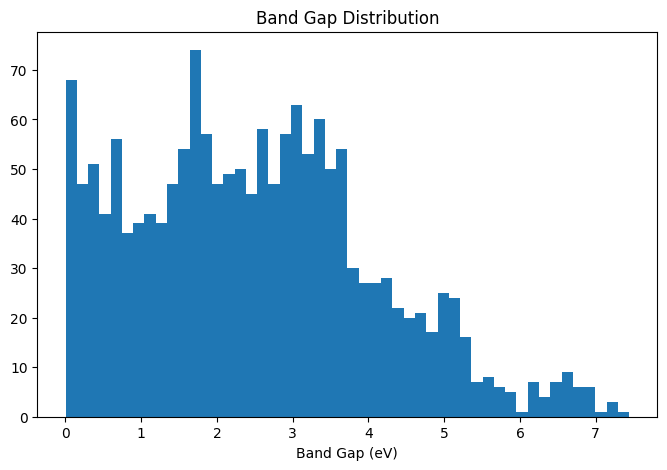

(1612, 49)


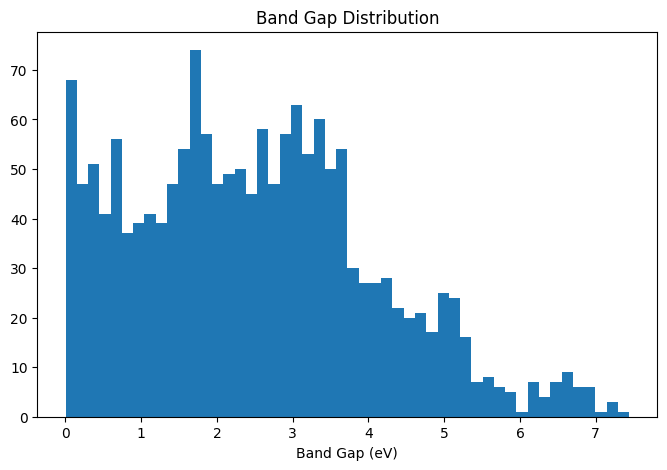

(1612, 38688)


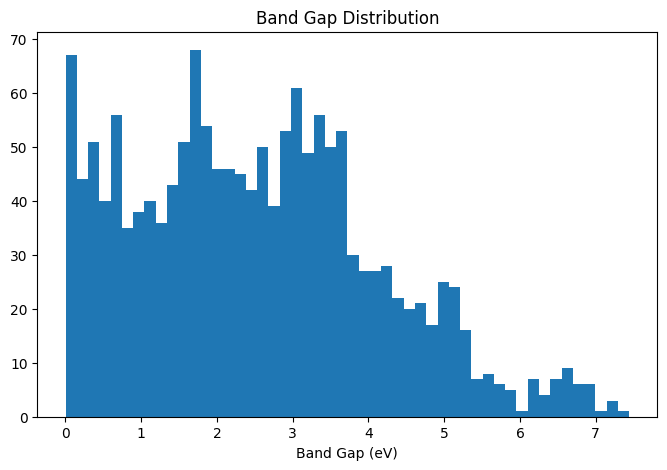

(1541, 49)


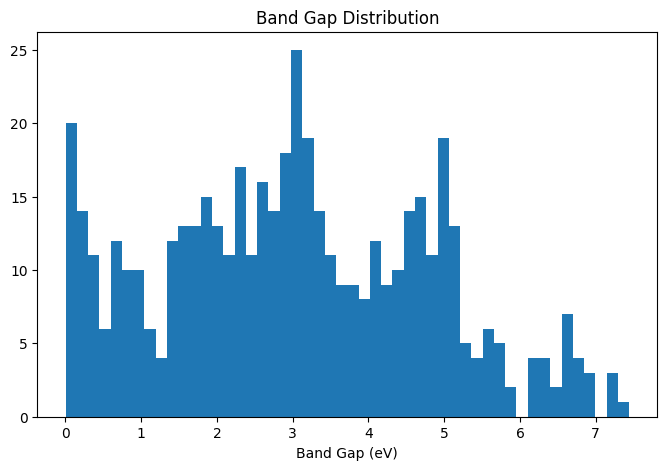

(494, 49)


In [175]:
# Pots the bad gaps to see if there are any outliers. Also prints the shape of the dataframes.
#Appends an instance of the class df_with_info to the list sotring them all for each data set
list_df_with_info = []
for name, df in all_df.items():
    plt.figure(figsize=(8, 5))
    plt.hist(df["band_gap"], bins=50)
    plt.xlabel("Band Gap (eV)")
    plt.title("Band Gap Distribution")
    plt.show()
    print(df.shape)
    list_df_with_info.append(df_with_info(name, df))

Seems like we dont really have outliers, in all the dataframes when it comes to the target variable y (band gap)

In [176]:
# for each df_with_info in the list_df_with_info, we create the X and y arrays, 
# and split the data into training and test sets and store them in the class
for df_info in list_df_with_info:
    df_info.X = df_info.df.select_dtypes(include=[np.number]).drop(columns=["band_gap"])
    df_info.y = np.asarray(df_info.df["band_gap"])
    df_info.X_train, df_info.X_test, df_info.y_train, df_info.y_test = train_test_split(
        df_info.X, df_info.y, test_size=0.1, random_state=9
    )

# Random Forest Regressor

In [177]:
list_df_rfr = copy.deepcopy(list_df_with_info)

## Hyperparameter Optimisation

In [178]:
def tune_random_forest_with_halving_cv(big_df_temp):
    """
    grid searches the hyperparameters of a random forest regressor using HalvingGridSearchCV. 

    Parameters:
        big_df_temp (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits 
    Returns:
        Hyperparameters and RMSE of the best model on the test set.
    """   
    # Define cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Define parameter grid
    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    }

    # Set up the HalvingGridSearchCV
    search = HalvingGridSearchCV(
        RandomForestRegressor(random_state=0),
        param_grid,
        cv=cv,
        factor=2,
        scoring="neg_mean_squared_error",
        verbose=1,
        n_jobs=-1,
    )

    # Fit model
    search.fit(big_df_temp.X_train, big_df_temp.y_train)

    # Save best estimator and metrics to big_df_temp
    best_model = search.best_estimator_
    y_pred = best_model.predict(big_df_temp.X_test)
    # Use mean_squared_error without 'squared' if your sklearn version does not support it
    try:
        rmse = mean_squared_error(big_df_temp.y_test, y_pred, squared=False)
    except TypeError:
        # For older sklearn versions
        rmse = mean_squared_error(big_df_temp.y_test, y_pred) ** 0.5

    print(f"🔍 Best hyperparameters for {big_df_temp.name}:")
    print(search.best_params_)
    print(f"📉 RMSE on full data with best params: {rmse:.4f}")

    return search.best_params_, rmse

In [179]:
# Iterate over the list of df_with_info instances and tune the random forest model for each

for df in list_df_rfr:
    best_params, rmse = tune_random_forest_with_halving_cv(df)
    print(f"Best parameters for {df.name}: {best_params}")
    print(f"RMSE: {rmse:.4f}")

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 90
max_resources_: 1450
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 18
n_resources: 90
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 1
n_candidates: 9
n_resources: 180
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 2
n_candidates: 5
n_resources: 360
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 3
n_candidates: 3
n_resources: 720
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 4
n_candidates: 2
n_resources: 1440
Fitting 5 folds for each of 2 candidates, totalling 10 fits
🔍 Best hyperparameters for df:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
📉 RMSE on full data with best params: 0.7308
Best parameters for df: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
RMSE: 0.7308
n_iterations: 5
n_required_iterations: 5
n_possible_i

Using repeated CV took way to long on my maschine, which is why we used halving gridsearch instead

In [180]:
def train_and_test_rfr_2(
    big_df_temp, test_size=0.1, store=True, plot=False, max_depth=None, n_estimators=200
):
    """
    Trains a Random Forest Regressor model on the provided dataframe and evaluates its performance.

    Parameters:
        big_df_temp (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
        test_size (float): Proportion of the dataset to include in the test split.
        store (bool): If True, stores the model and performance metrics in the df_with_info instance.
        plot (bool): If True, plots the predicted values against the true values.
        max_depth (int or None): Maximum depth of the tree. 
    Returns:
        Returns the df with additional column ase, containing ASE Atoms objects for each entry.
    """   
    # big_df_temp.X = big_df_temp.df.select_dtypes(include=[np.number]).drop(
    #     columns=["band_gap"]
    # )

    # big_df_temp.y = np.asarray(big_df_temp.df["band_gap"])
    # # Split the data into training and testing sets
    # X_train, X_test, y_train, y_test = train_test_split(
    #     big_df_temp.X, big_df_temp.y, test_size=test_size, random_state=9
    # )

    # Create a Random Forest Regressor model
    "These are the values from the paper"
    rfr = GridSearchCV(
        RandomForestRegressor(),
        {
            "max_depth": max_depth,
            "n_estimators": n_estimators,
            "random_state": [0],
        },
        cv=5,
    )

    # Fit the model to the training data
    rfr.fit(big_df_temp.X_train, big_df_temp.y_train)
    big_df_temp.model = rfr.best_estimator_
    # Make predictions on the test set
    y_predicted = rfr.predict(big_df_temp.X_test)
    # plot the predicted values against the true values and add a line for the ideal prediction

    r2_score = rfr.score(big_df_temp.X_train, big_df_temp.y_train)

    r2_score1 = rfr.score(big_df_temp.X_test, big_df_temp.y_test)
    rmse = mean_squared_error(big_df_temp.y_test, y_predicted)
    rmae = mean_absolute_error(big_df_temp.y_test, y_predicted)
    "Plots the predicted values against the true values"

    if plot:
        # plt.figure(figsize=(5, 5))
        # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        # plt.scatter(y_test, y_predicted)
        # plt.xlabel("True Values")
        # plt.ylabel("Predictions")
        # plt.title("RFR: Band Gap for " + big_df_temp.name)
        # plt.savefig(big_df_temp.name + "_RFR_band_gap.png")
        # plt.show()

        print("--------------------------------------------")
        print("For dataframe:", big_df_temp.name)
        print("RFR Model| R2 sq on train set: %.4f" % r2_score)
        print("RFR Model| R2 sq on test set: %.4f" % r2_score1)
        print(
            "RFR Model| MSE on test set: %.4f" % mean_squared_error(big_df_temp.y_test, y_predicted)
        )
        print(
            "RFR Model| MAE on test set: %.4f"
            % mean_absolute_error(big_df_temp.y_test, y_predicted)
        )

        plt.figure(figsize=(5, 5))
        plt.plot(
            [big_df_temp.y_test.min(), big_df_temp.y_test.max()], [big_df_temp.y_test.min(), big_df_temp.y_test.max()], "k--", lw=2
        )
        plt.scatter(big_df_temp.y_test, y_predicted)
        plt.xlabel("True Values")
        plt.ylabel("Predictions")
        plt.title("RFR: Band Gap for " + big_df_temp.name)
        plt.savefig(big_df_temp.name + "_RFR_band_gap.png", dpi=300)
        plt.show()

    "look at the feature importance"

    importances = rfr.best_estimator_.feature_importances_
    feature_names = big_df_temp.X_train.columns

    # DataFrame with individual importances
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})

    # Aggregate all soap_X components into one "SOAP" feature
    soap_start_index = 44  # index where soap columns start
    soap_columns = feature_names[soap_start_index:]

    # Sum their importance
    soap_importance = importance_df[importance_df["Feature"].isin(soap_columns)][
        "Importance"
    ].sum()

    # Add it as a row in the dataframe
    high_level_importance_df = importance_df[
        ~importance_df["Feature"].isin(soap_columns)
    ].copy()
    high_level_importance_df = pd.concat(
        [
            high_level_importance_df,
            pd.DataFrame([{"Feature": "SOAP", "Importance": soap_importance}]),
        ],
        ignore_index=True,
    )

    # Sort and show
    high_level_importance_df = high_level_importance_df.sort_values(
        by="Importance", ascending=False
    )

    # print("Grouped Feature Importances for " + big_df_temp.name)
    # print(high_level_importance_df.head(5))

    if store:
        big_df_temp.features = high_level_importance_df
        big_df_temp.R2_train = r2_score
        big_df_temp.R2_test = r2_score1
        big_df_temp.RMSE = rmse
        print("RMSE: ", rmse)
        print(big_df_temp.RMSE)
        big_df_temp.RMAE = rmae

        # big_df_temp.X_train = X_train
        # big_df_temp.X_test = X_test
        # big_df_temp.y_train = y_train
        # big_df_temp.y_test = y_test
        # big_df_temp.print()
        return
    else:

        print("RMSE: ", rmse)
        print("RMAE: ", rmae)

        return rmse

--------------------------------------------
For dataframe: df
RFR Model| R2 sq on train set: 0.9670
RFR Model| R2 sq on test set: 0.7784
RFR Model| MSE on test set: 0.5341
RFR Model| MAE on test set: 0.5060


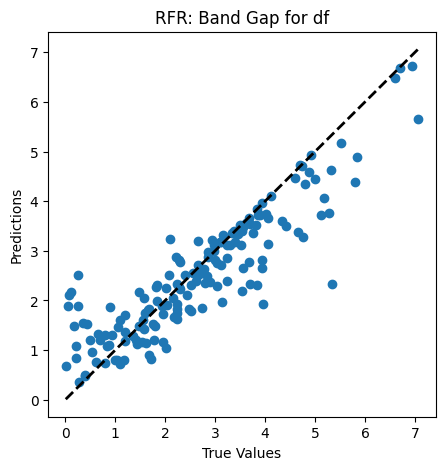

RMSE:  0.5341359111787563
0.5341359111787563
--------------------------------------------
For dataframe: df_soap
RFR Model| R2 sq on train set: 0.9673
RFR Model| R2 sq on test set: 0.7830
RFR Model| MSE on test set: 0.5229
RFR Model| MAE on test set: 0.5125


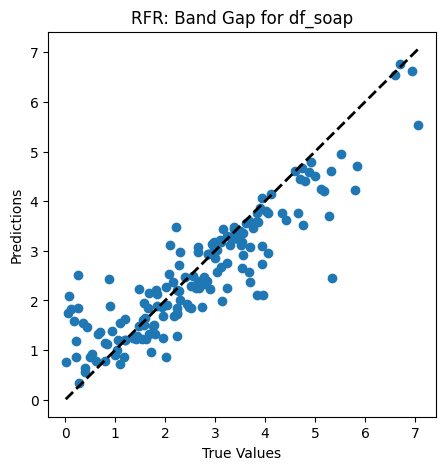

RMSE:  0.5228810958830368
0.5228810958830368
--------------------------------------------
For dataframe: df_leadfree
RFR Model| R2 sq on train set: 0.9655
RFR Model| R2 sq on test set: 0.7980
RFR Model| MSE on test set: 0.5251
RFR Model| MAE on test set: 0.5272


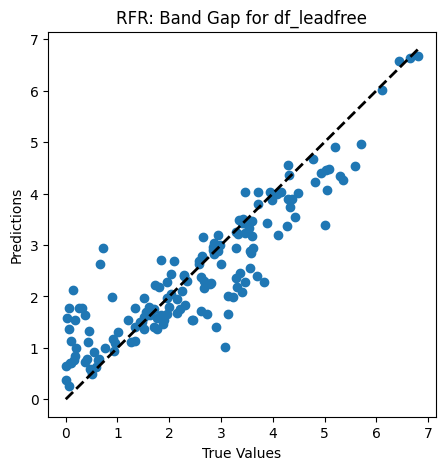

RMSE:  0.525060582341267
0.525060582341267
--------------------------------------------
For dataframe: df_abundant
RFR Model| R2 sq on train set: 0.9630
RFR Model| R2 sq on test set: 0.8126
RFR Model| MSE on test set: 0.5893
RFR Model| MAE on test set: 0.5331


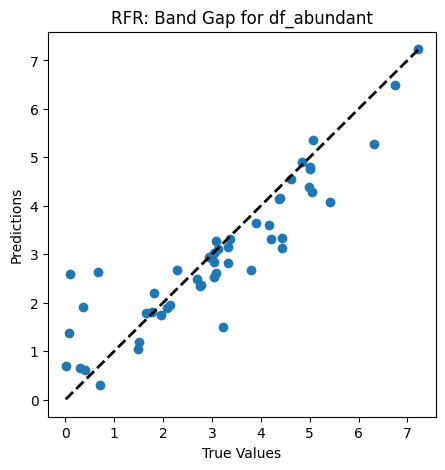

RMSE:  0.5892530791794335
0.5892530791794335


In [181]:
train_and_test_rfr_2(
    list_df_rfr[0], 0.1, store=True, plot=True, max_depth=[20], n_estimators=[200]
)
train_and_test_rfr_2(
    list_df_rfr[1], 0.1, True, True, max_depth=[20], n_estimators=[200]
)
train_and_test_rfr_2(
    list_df_rfr[2], 0.1, True, True, max_depth=[20], n_estimators=[200]
)
train_and_test_rfr_2(
    list_df_rfr[3], 0.1, True, True, max_depth=[10], n_estimators=[200]
)

In [ ]:
def evaluate_model_with_cv(model, big_df_temp, random_state):
    """
    Evaluates the performance of a given model using K-Fold cross-validation on the provided dataframe.

    Parameters:
        model: The machine learning model to be evaluated.
        big_df_temp (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
        random_state (int): Random seed for reproducibility.
    Returns:
        A dictionary containing the average metrics across all folds.
        The metrics include RMSE, RMAE, R2_train, and R2_test.
    """   
    # Initialize KFold
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    # Lists to store metrics
    metrics = {
        "RMSE": [],
        "RMAE": [],
        "R2_train": [],
        "R2_test": [],
    }

    # Iterate over folds
    for train_index, test_index in kf.split(big_df_temp.X):
        # Use .iloc to index rows by position
        X_train_fold = big_df_temp.X.iloc[train_index]
        X_test_fold = big_df_temp.X.iloc[test_index]
        y_train_fold = big_df_temp.y[train_index]
        y_test_fold = big_df_temp.y[test_index]

        # Train model
        model.fit(X_train_fold, y_train_fold)

        # Predict
        y_pred_fold = model.predict(X_test_fold)

        # Calculate metrics
        metrics["RMSE"].append(mean_squared_error(y_test_fold, y_pred_fold))
        metrics["RMAE"].append(mean_absolute_error(y_test_fold, y_pred_fold))
        metrics["R2_train"].append(model.score(X_train_fold, y_train_fold))
        metrics["R2_test"].append(model.score(X_test_fold, y_test_fold))

    # Print metrics
    metric_display_names = {
        "RMSE": "RMSE",
        "RMAE": "RMAE",
        "R2_train": "R2_train",
        "R2_test": "R2_test",
    }
    for metric_name, values in metrics.items():
        display_name = metric_display_names[metric_name]
        print(
            f"Average {display_name}: {np.mean(values):.4f} \t and std err: {stats.sem(values):.4f}"
        )

    return metrics

In [ ]:
# Evaluate the models for each DataFrame in the list_df_rfr
for df in list_df_rfr:
    print(f"Evaluating model for {df.name} with 5-fold cross-validation:")
    metrics = evaluate_model_with_cv(df.model, df, random_state=42)
    print("\n")  # Add a newline for better readability between different DataFrames

Evaluating model for df with 5-fold cross-validation:
Average RMSE: 0.6403 	 and std err: 0.0350
Average RMAE: 0.5502 	 and std err: 0.0097
Average R2_train: 0.9656 	 and std err: 0.0006
Average R2_test: 0.7437 	 and std err: 0.0150


Evaluating model for df_soap with 5-fold cross-validation:
Average RMSE: 0.6156 	 and std err: 0.0369
Average RMAE: 0.5440 	 and std err: 0.0116
Average R2_train: 0.9657 	 and std err: 0.0006
Average R2_test: 0.7536 	 and std err: 0.0158


Evaluating model for df_leadfree with 5-fold cross-validation:
Average RMSE: 0.6708 	 and std err: 0.0315
Average RMAE: 0.5600 	 and std err: 0.0092
Average R2_train: 0.9653 	 and std err: 0.0003
Average R2_test: 0.7405 	 and std err: 0.0113


Evaluating model for df_abundant with 5-fold cross-validation:
Average RMSE: 0.7957 	 and std err: 0.1061
Average RMAE: 0.5758 	 and std err: 0.0272
Average R2_train: 0.9627 	 and std err: 0.0018
Average R2_test: 0.7364 	 and std err: 0.0456




### Plot Feature Importances for Randomforest with and without the soaps

In [ ]:
# Plot the feature impotance of the firsttwo entries in the list list_df_rfr
def plot_feature_importance(df_info):
    """
    Plots the feature importance of the Random Forest Regressor model for the given df_with_info instance.

    Parameters:
        df_info (df_with_info):  instance of the df_with_info class containing the features to be plotted.
    Returns:
        None, but displays a horizontal bar plot of the top 10 features and their importance.
    """   
    if df_info.features is not None:
        plt.figure(figsize=(10, 6))
        plt.barh(
            df_info.features["Feature"].head(10),
            df_info.features["Importance"].head(10),
            color="skyblue",
        )
        plt.xlabel("Importance")
        plt.title(f"Feature Importance for {df_info.name}")
        plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
        plt.show()
        # adjust the x and y lim, only include the top 10 features

    else:
        print(f"No features available for {df_info.name}.")

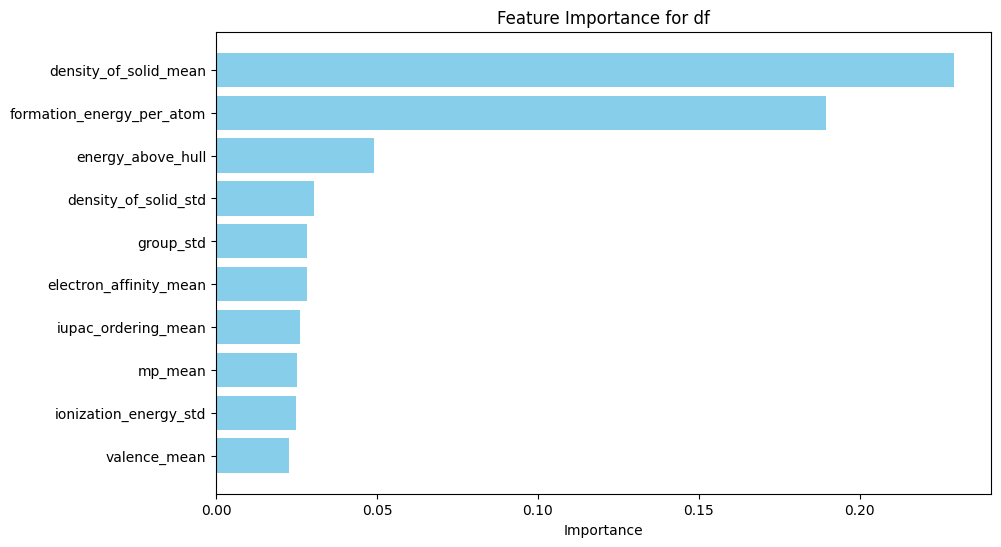

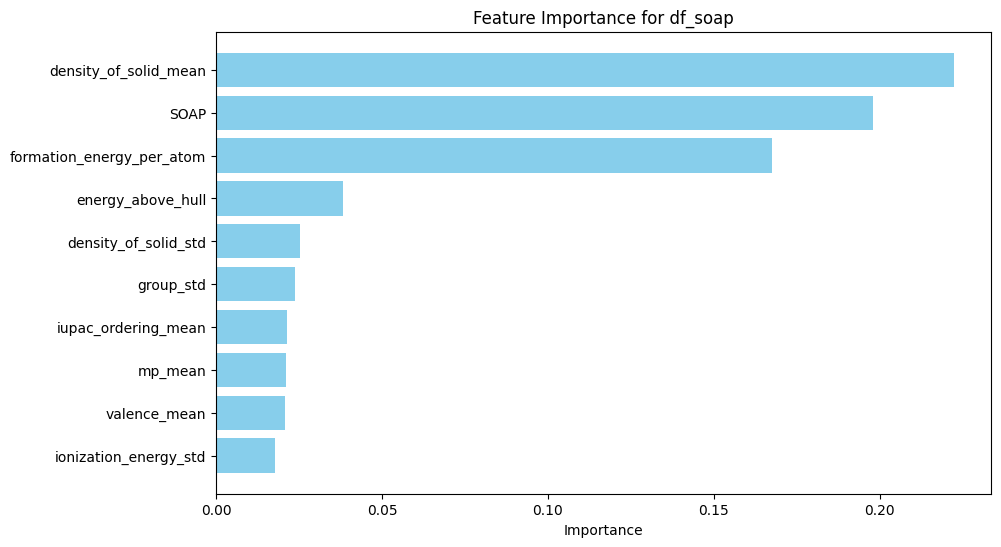

In [113]:
for df in list_df_rfr[0:2]:
    plot_feature_importance(df)

# SVR

In [60]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

In [61]:
list_df_SVR = copy.deepcopy(list_df_with_info)

In [ ]:
from sklearn.model_selection import HalvingGridSearchCV, KFold
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


def tune_svr_with_halving_cv(big_df_temp):
    """
    Tunes the hyperparameters of a Support Vector Regressor (SVR) using HalvingGridSearchCV.

    Parameters:
        big_df_temp (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
    Returns:
        A tuple containing the best hyperparameters and the RMSE of the best model on the test set.
        Prints the best hyperparameters and RMSE.
    """   

    # Define cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Define parameter grid (for SVR with preprocessing pipeline)
    param_grid = {
        "svr__C": [0.1, 1, 10],
        "svr__epsilon": [0.001, 0.01, 0.1],
        "svr__kernel": ["rbf", "linear"],
    }

    # Create pipeline with StandardScaler (important for SVR)
    pipeline = make_pipeline(StandardScaler(), SVR())

    # Set up the HalvingGridSearchCV
    search = HalvingGridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        factor=2,
        scoring="neg_mean_squared_error",
        verbose=1,
        n_jobs=-1,
    )

    # Fit model
    search.fit(big_df_temp.X_train, big_df_temp.y_train)

    # Save best estimator and metrics to big_df_temp
    best_model = search.best_estimator_
    y_pred = best_model.predict(big_df_temp.X_test)
    try:
        rmse = mean_squared_error(big_df_temp.y_test, y_pred, squared=False)
    except TypeError:
        rmse = mean_squared_error(big_df_temp.y_test, y_pred) ** 0.5

    print(f"🔍 Best hyperparameters for {big_df_temp.name}:")
    print(search.best_params_)
    print(f"📉 RMSE on full data with best params: {rmse:.4f}")

    return search.best_params_, rmse

In [ ]:
# Iterate over the list of df_with_info instances and tune the SVR model for each
for df in list_df_SVR:
    best_params, rmse = tune_svr_with_halving_cv(df)
    print(f"Best parameters for {df.name}: {best_params}")
    print(f"RMSE: {rmse:.4f}")

n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 90
max_resources_: 1450
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 18
n_resources: 90
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 1
n_candidates: 9
n_resources: 180
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 2
n_candidates: 5
n_resources: 360
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 3
n_candidates: 3
n_resources: 720
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 4
n_candidates: 2
n_resources: 1440
Fitting 5 folds for each of 2 candidates, totalling 10 fits
🔍 Best hyperparameters for df:
{'svr__C': 10, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}
📉 RMSE on full data with best params: 0.7247
Best parameters for df: {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}
RMSE: 0.7247
n_iterations: 5
n_required_iterations: 5
n_possible_iterations:

In [ ]:
def train_SVR(df, C=100, epsilon=0.001):
    """
    Trains a Support Vector Regressor (SVR) model on the provided dataframe and evaluates its performance.

    Parameters:
        df (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
        C (list): List of regularization parameters for the SVR model.
        epsilon (list): List of epsilon values for the SVR model.
    Returns:
        None, but prints the performance metrics of the SVR model and displays a scatter plot of true vs predicted values.
        The model is stored in the df_with_info instance.
    """   

    steps = [("scaler", StandardScaler()), ("SVM", SVR())]
    pipeline = Pipeline(steps)
    grid = GridSearchCV(
        pipeline,
        param_grid={
            "SVM__C": C,
            "SVM__gamma": ["auto"],
            "SVM__kernel": ["rbf"],
            "SVM__epsilon": epsilon,
        },
        cv=5,
    )
    grid.fit(df.X_train, df.y_train)
    df.model = grid.best_estimator_
    svr_score = grid.score(df.X_train, df.y_train)
    svr_score1 = grid.score(df.X_test, df.y_test)
    y_predicted = grid.predict(df.X_test)

    # print results + scatterplot
    print("--------------------------------------------")
    print("For dataframe:", df.name)
    print("SVR Model| R2 sq on train set: %.4f" % svr_score)
    print("SVR Model| R2 sq on test set: %.4f" % svr_score1)
    print(
        "SVR Model| MSE on test set: %.4f" % mean_squared_error(df.y_test, y_predicted)
    )
    print(
        "SVR Model| MAE on test set: %.4f" % mean_absolute_error(df.y_test, y_predicted)
    )
    plt.figure(figsize=(5, 5))
    plt.plot(
        [df.y_test.min(), df.y_test.max()],
        [df.y_test.min(), df.y_test.max()],
        "k--",
        lw=2,
    )
    plt.scatter(df.y_test, y_predicted)
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    plt.title("SVR: Band Gap for " + df.name)

    plt.show()

    print("--------------------------------------------")
    return

--------------------------------------------
For dataframe: df
SVR Model| R2 sq on train set: 0.9456
SVR Model| R2 sq on test set: 0.7663
SVR Model| MSE on test set: 0.5633
SVR Model| MAE on test set: 0.5326


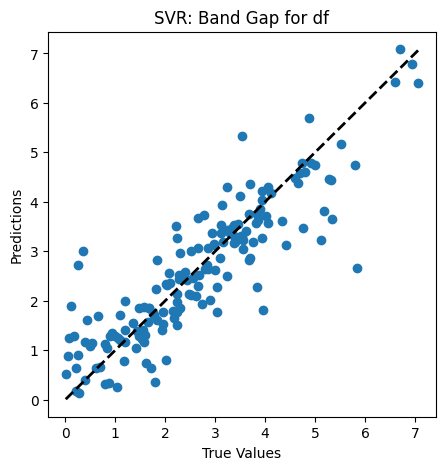

--------------------------------------------
--------------------------------------------
For dataframe: df_soap
SVR Model| R2 sq on train set: 0.9648
SVR Model| R2 sq on test set: 0.3061
SVR Model| MSE on test set: 1.6725
SVR Model| MAE on test set: 0.9395


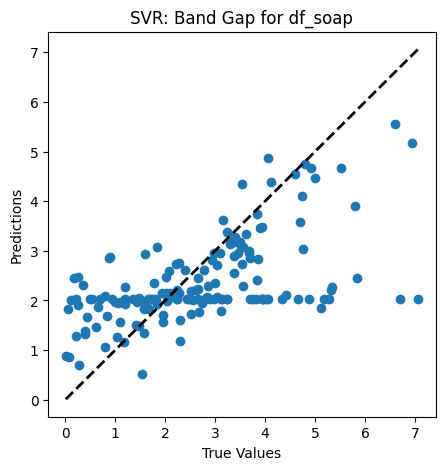

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
SVR Model| R2 sq on train set: 0.9488
SVR Model| R2 sq on test set: 0.7890
SVR Model| MSE on test set: 0.5486
SVR Model| MAE on test set: 0.4935


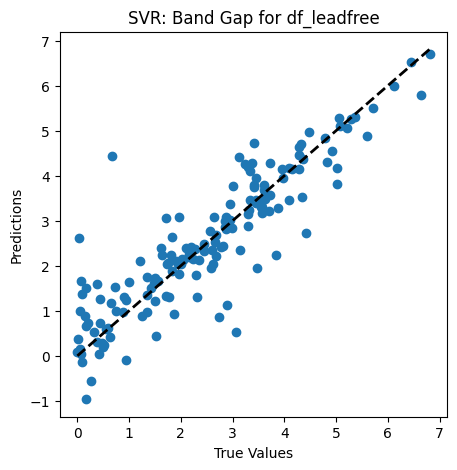

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
SVR Model| R2 sq on train set: 0.8870
SVR Model| R2 sq on test set: 0.7608
SVR Model| MSE on test set: 0.7521
SVR Model| MAE on test set: 0.5889


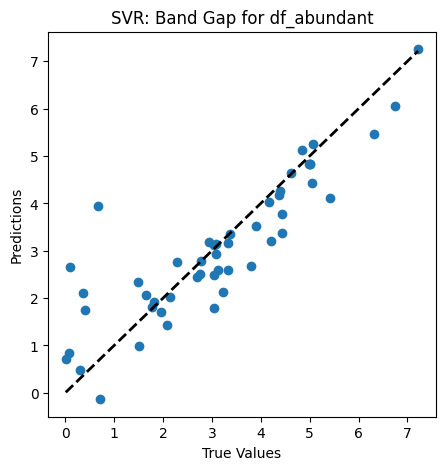

--------------------------------------------
--------------------------------------------
For dataframe: df
SVR Model| R2 sq on train set: 0.9456
SVR Model| R2 sq on test set: 0.7663
SVR Model| MSE on test set: 0.5633
SVR Model| MAE on test set: 0.5326


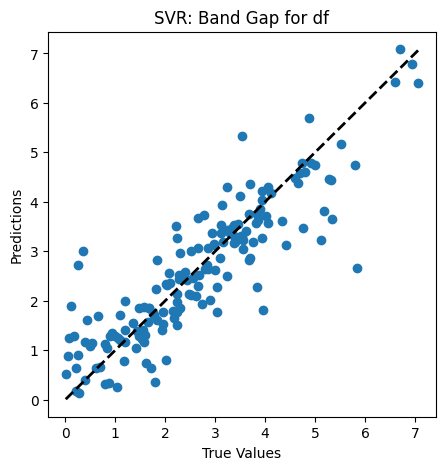

--------------------------------------------
--------------------------------------------
For dataframe: df
SVR Model| R2 sq on train set: 0.8691
SVR Model| R2 sq on test set: 0.7821
SVR Model| MSE on test set: 0.5252
SVR Model| MAE on test set: 0.5203


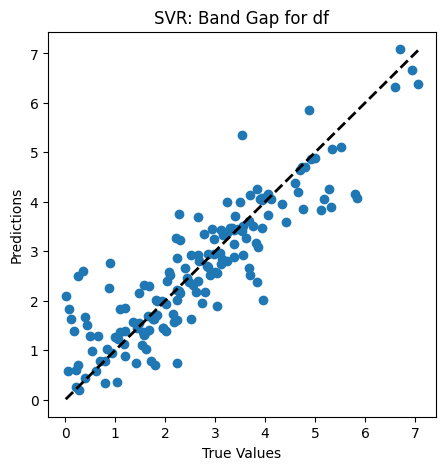

--------------------------------------------
--------------------------------------------
For dataframe: df_soap
SVR Model| R2 sq on train set: 0.9988
SVR Model| R2 sq on test set: 0.3548
SVR Model| MSE on test set: 1.5550
SVR Model| MAE on test set: 0.9032


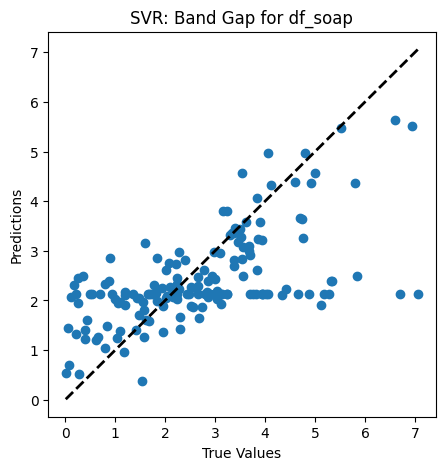

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
SVR Model| R2 sq on train set: 0.8702
SVR Model| R2 sq on test set: 0.7786
SVR Model| MSE on test set: 0.5757
SVR Model| MAE on test set: 0.4884


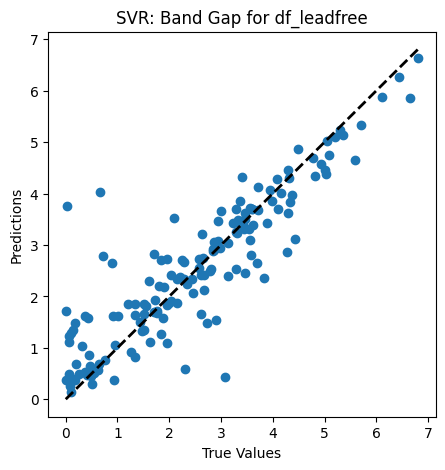

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
SVR Model| R2 sq on train set: 0.8858
SVR Model| R2 sq on test set: 0.7491
SVR Model| MSE on test set: 0.7887
SVR Model| MAE on test set: 0.5973


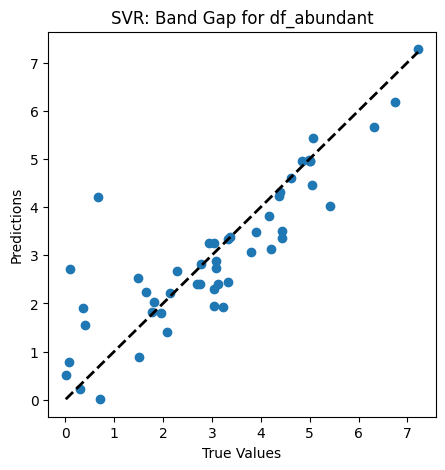

--------------------------------------------


In [ ]:
train_SVR(list_df_SVR[0], C=[10], epsilon=[0.1])
train_SVR(list_df_SVR[1], C=[100], epsilon=[0.001])
train_SVR(list_df_SVR[2], C=[10], epsilon=[0.1])
train_SVR(list_df_SVR[3], C=[10], epsilon=[0.01])

In [ ]:
# Evaluate the models for each DataFrame in the list_df_SVR
for df in list_df_SVR:
    print(f"Evaluating model for {df.name} with 5-fold cross-validation:")
    metrics = evaluate_model_with_cv(df.model, df, random_state=42)
    print("\n")  # Add a newline for better readability between different DataFrames

Evaluating model for df with 5-fold cross-validation:
Average RMSE: 0.7010 	 and std err: 0.0381
Average RMAE: 0.5501 	 and std err: 0.0162
Average R2_train: 0.9508 	 and std err: 0.0020
Average R2_test: 0.7210 	 and std err: 0.0053


Evaluating model for df_soap with 5-fold cross-validation:
Average RMSE: 1.4636 	 and std err: 0.0502
Average RMAE: 0.9024 	 and std err: 0.0159
Average R2_train: 0.9988 	 and std err: 0.0002
Average R2_test: 0.4143 	 and std err: 0.0208


Evaluating model for df_leadfree with 5-fold cross-validation:
Average RMSE: 0.6951 	 and std err: 0.0420
Average RMAE: 0.5422 	 and std err: 0.0116
Average R2_train: 0.9506 	 and std err: 0.0019
Average R2_test: 0.7307 	 and std err: 0.0158


Evaluating model for df_abundant with 5-fold cross-validation:
Average RMSE: 1.0146 	 and std err: 0.2554
Average RMAE: 0.6204 	 and std err: 0.0624
Average R2_train: 0.9500 	 and std err: 0.0055
Average R2_test: 0.6699 	 and std err: 0.0867




# KNR

In [101]:
from sklearn.neighbors import KNeighborsRegressor

In [102]:
list_df_KNR = copy.deepcopy(list_df_with_info)

In [ ]:

def tune_knn_with_halving_cv(big_df_temp):
    """
    Tunes the hyperparameters of a K-Nearest Neighbors Regressor (KNeighborsRegressor) using HalvingGridSearchCV.

    Parameters:
        big_df_temp (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
    Returns:
        A tuple containing the best hyperparameters and the RMSE of the best model on the test set.
        Prints the best hyperparameters and RMSE.
    """   

    # Define cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Define parameter grid
    param_grid = {
        "n_neighbors": [3, 5, 10, 20],
        "weights": ["uniform", "distance"],
        "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    }

    # Set up the HalvingGridSearchCV
    search = HalvingGridSearchCV(
        KNeighborsRegressor(),
        param_grid,
        cv=cv,
        factor=2,
        scoring="neg_mean_squared_error",
        verbose=1,
        n_jobs=-1,
    )

    # Fit model
    search.fit(big_df_temp.X_train, big_df_temp.y_train)

    # Save best estimator and metrics to big_df_temp
    best_model = search.best_estimator_
    y_pred = best_model.predict(big_df_temp.X_test)

    try:
        rmse = mean_squared_error(big_df_temp.y_test, y_pred, squared=False)
    except TypeError:
        rmse = mean_squared_error(big_df_temp.y_test, y_pred) ** 0.5

    print(f"🔍 Best hyperparameters for {big_df_temp.name}:")
    print(search.best_params_)
    print(f"📉 RMSE on full data with best params: {rmse:.4f}")

    return search.best_params_, rmse

In [ ]:
# Iterate over the list of df_with_info instances and tune the KNN model for each
for df in list_df_KNR:
    best_params, rmse = tune_knn_with_halving_cv(df)
    print(f"Best parameters for {df.name}: {best_params}")
    print(f"RMSE: {rmse:.4f}")

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 45
max_resources_: 1450
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 32
n_resources: 45
Fitting 5 folds for each of 32 candidates, totalling 160 fits
----------
iter: 1
n_candidates: 16
n_resources: 90
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 2
n_candidates: 8
n_resources: 180
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 3
n_candidates: 4
n_resources: 360
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 4
n_candidates: 2
n_resources: 720
Fitting 5 folds for each of 2 candidates, totalling 10 fits
----------
iter: 5
n_candidates: 1
n_resources: 1440
Fitting 5 folds for each of 1 candidates, totalling 5 fits
🔍 Best hyperparameters for df:
{'algorithm': 'ball_tree', 'n_neighbors': 5, 'weights': 'distance'}
📉 RMSE on full data with best params: 1.2015
Best parameters for df: {'algorithm

/Users/dominikgotz/Documents/Digichem/.conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/dominikgotz/Documents/Digichem/.conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dominikgotz/Documents/Digichem/.conda/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dominikgotz/Documents/Digichem/.conda/lib/python3.11/site-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_calle

In [ ]:
def train_and_test_knn(df, n_neighbors=[10], algorithm=["auto"]):
    """
    Trains a K-Nearest Neighbors Regressor model on the provided dataframe and evaluates its performance.

    Parameters:
        df (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
        n_neighbors (list): List of number of neighbors to use in the KNN model.
        algorithm (list): List of algorithms to use in the KNN model.    
    Returns:
        None, but prints the performance metrics of the KNN model and displays a scatter plot of true vs predicted values.
        The model is stored in the df_with_info instance.
    """   
    knr = GridSearchCV(
        KNeighborsRegressor(),
        {"n_neighbors": n_neighbors, "algorithm": algorithm, "weights": ["distance"]},
        cv=5,
    )
    knr.fit(df.X_train, df.y_train)
    df.model = knr.best_estimator_
    knr_score = knr.score(df.X_train, df.y_train)
    knr_score1 = knr.score(df.X_test, df.y_test)
    y_predicted9 = knr.predict(df.X_test)

    # print results + scatterplot
    print("--------------------------------------------")
    print("For dataframe:", df.name)
    print("KNR Model| R2 sq on train set: %.4f" % knr_score)
    print("KNR Model| R2 sq on test set: %.4f" % knr_score1)
    print(
        "KNR Model| MSE on test set: %.4f" % mean_squared_error(df.y_test, y_predicted9)
    )
    print(
        "KNR Model| MAE on test set: %.4f"
        % mean_absolute_error(df.y_test, y_predicted9)
    )

    plt.figure(figsize=(5, 5))
    plt.plot(
        [df.y_test.min(), df.y_test.max()],
        [df.y_test.min(), df.y_test.max()],
        "k--",
        lw=2,
    )
    plt.scatter(df.y_test, y_predicted9)
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    plt.title("KNR: Band Gap for " + df.name)
    plt.savefig(df.name + "_KNR_band_gap.png", dpi=300)
    plt.show()

    print("--------------------------------------------")

--------------------------------------------
For dataframe: df
KNR Model| R2 sq on train set: 1.0000
KNR Model| R2 sq on test set: 0.4222
KNR Model| MSE on test set: 1.4435
KNR Model| MAE on test set: 0.7868


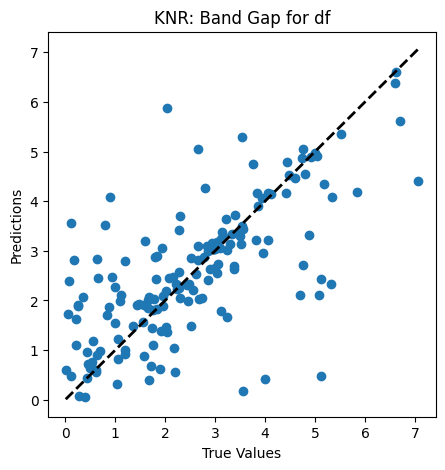

--------------------------------------------
--------------------------------------------
For dataframe: df_soap
KNR Model| R2 sq on train set: 1.0000
KNR Model| R2 sq on test set: 0.5535
KNR Model| MSE on test set: 1.1154
KNR Model| MAE on test set: 0.7960


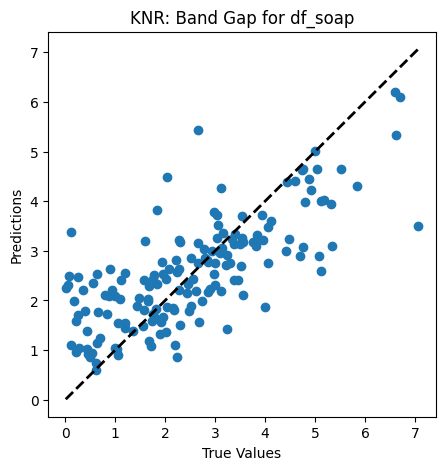

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
KNR Model| R2 sq on train set: 1.0000
KNR Model| R2 sq on test set: 0.4842
KNR Model| MSE on test set: 1.2944
KNR Model| MAE on test set: 0.8089


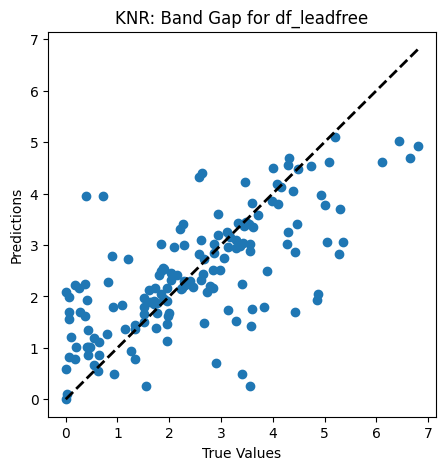

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
KNR Model| R2 sq on train set: 1.0000
KNR Model| R2 sq on test set: 0.5594
KNR Model| MSE on test set: 1.0695
KNR Model| MAE on test set: 0.6866


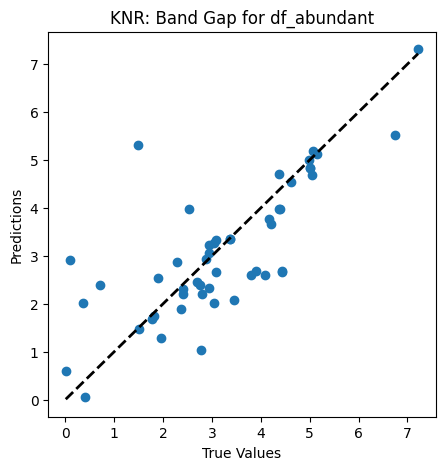

--------------------------------------------


In [ ]:
# Train and test the KNN model for each DataFrame in the list_df_KNR
train_and_test_knn(list_df_KNR[0], n_neighbors=[5], algorithm=["ball_tree"])
train_and_test_knn(list_df_KNR[1], n_neighbors=[20], algorithm=["ball_tree"])
train_and_test_knn(list_df_KNR[2], n_neighbors=[20], algorithm=["ball_tree"])
train_and_test_knn(list_df_KNR[3], n_neighbors=[10], algorithm=["brute"])

In [ ]:
# Evaluate the models for each DataFrame in the list_df_KNR
for df in list_df_KNR:
    print(f"Evaluating model for {df.name} with 5-fold cross-validation:")
    metrics = evaluate_model_with_cv(df.model, df, random_state=42)
    print("\n")  # Add a newline for better readability between different DataFrames

Evaluating model for df with 5-fold cross-validation:
Average RMSE: 1.3359 	 and std err: 0.0564
Average RMAE: 0.7914 	 and std err: 0.0096
Average R2_train: 1.0000 	 and std err: 0.0000
Average R2_test: 0.4626 	 and std err: 0.0347


Evaluating model for df_soap with 5-fold cross-validation:
Average RMSE: 1.3387 	 and std err: 0.0498
Average RMAE: 0.8271 	 and std err: 0.0074
Average R2_train: 1.0000 	 and std err: 0.0000
Average R2_test: 0.4619 	 and std err: 0.0313


Evaluating model for df_leadfree with 5-fold cross-validation:
Average RMSE: 1.2983 	 and std err: 0.0713
Average RMAE: 0.7822 	 and std err: 0.0244
Average R2_train: 1.0000 	 and std err: 0.0000
Average R2_test: 0.4985 	 and std err: 0.0173


Evaluating model for df_abundant with 5-fold cross-validation:
Average RMSE: 1.4944 	 and std err: 0.1365
Average RMAE: 0.8021 	 and std err: 0.0193
Average R2_train: 1.0000 	 and std err: 0.0000
Average R2_test: 0.5177 	 and std err: 0.0450




# GBR

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

In [41]:
list_df_GBR = copy.deepcopy(list_df_with_info)

In [ ]:
def tune_gbr_with_halving_cv(big_df_temp):
    """
    Tunes the hyperparameters of a Gradient Boosting Regressor (GBR) using HalvingGridSearchCV.

    Parameters:
        big_df_temp (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
    Returns:
        A tuple containing the best hyperparameters and the RMSE of the best model on the test set.
        Prints the best hyperparameters and RMSE.
    """   

    # Define cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Define parameter grid for GradientBoostingRegressor
    param_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 10],
        "min_samples_split": [2, 5],
    }

    # Set up the HalvingGridSearchCV
    search = HalvingGridSearchCV(
        GradientBoostingRegressor(random_state=0),
        param_grid,
        cv=cv,
        factor=2,
        scoring="neg_mean_squared_error",
        verbose=1,
        n_jobs=-1,
    )

    # Fit model
    search.fit(big_df_temp.X_train, big_df_temp.y_train)

    # Save best estimator and metrics to big_df_temp
    best_model = search.best_estimator_
    y_pred = best_model.predict(big_df_temp.X_test)
    try:
        rmse = mean_squared_error(big_df_temp.y_test, y_pred, squared=False)
    except TypeError:
        rmse = mean_squared_error(big_df_temp.y_test, y_pred) ** 0.5

    print(f"🔍 Best hyperparameters for {big_df_temp.name}:")
    print(search.best_params_)
    print(f"📉 RMSE on full data with best params: {rmse:.4f}")

    return search.best_params_, rmse

In [ ]:
# Iterate over the list of df_with_info instances and tune the Gradient Boosting Regressor model for each
for df in list_df_GBR:
    best_params, rmse = tune_gbr_with_halving_cv(df)
    print(f"Best parameters for {df.name}: {best_params}")
    print(f"RMSE: {rmse:.4f}")

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 45
max_resources_: 1450
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 36
n_resources: 45
Fitting 5 folds for each of 36 candidates, totalling 180 fits
----------
iter: 1
n_candidates: 18
n_resources: 90
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 2
n_candidates: 9
n_resources: 180
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 3
n_candidates: 5
n_resources: 360
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 4
n_candidates: 3
n_resources: 720
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 5
n_candidates: 2
n_resources: 1440
Fitting 5 folds for each of 2 candidates, totalling 10 fits
🔍 Best hyperparameters for df:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
📉 RMSE on full data with best params: 0.7004
Best parameters fo

In [ ]:
def train_GBR(df, n_estimators=[100], learning_rate=[0.1], max_depth=[3]):
    """
    Trains a Gradient Boosting Regressor model on the provided dataframe and evaluates its performance.

    Parameters:
        df (df_with_info):  instance of the df_with_info class containing the data to be used for training and testing. like train and test splits
        n_estimators (list): List of number of estimators to use in the GBR model.
        learning_rate (list): List of learning rates to use in the GBR model.
        max_depth (list): List of maximum depths to use in the GBR model.
    Returns:
        None, but prints the performance metrics of the GBR model and displays a scatter plot of true vs predicted values.
        The model is stored in the df_with_info instance.
    """   
    gbr = GridSearchCV(
        GradientBoostingRegressor(),
        {
            "n_estimators": n_estimators,
            "learning_rate": learning_rate,
            "max_depth": max_depth,
        },
        cv=5,
    )
    gbr.fit(df.X_train, df.y_train)
    df.model = gbr.best_estimator_
    gbr_score = gbr.score(df.X_train, df.y_train)
    gbr_score1 = gbr.score(df.X_test, df.y_test)
    y_predicted9 = gbr.predict(df.X_test)

    # print results + scatterplot
    print("--------------------------------------------")
    print("For dataframe:", df.name)
    print("GBR Model| R2 sq on train set: %.4f" % gbr_score)
    print("GBR Model| R2 sq on test set: %.4f" % gbr_score1)
    print(
        "GBR Model| MSE on test set: %.4f" % mean_squared_error(df.y_test, y_predicted9)
    )
    print(
        "GBR Model| MAE on test set: %.4f"
        % mean_absolute_error(df.y_test, y_predicted9)
    )

    plt.figure(figsize=(5, 5))
    plt.plot(
        [df.y_test.min(), df.y_test.max()],
        [df.y_test.min(), df.y_test.max()],
        "k--",
        lw=2,
    )
    plt.scatter(df.y_test, y_predicted9)
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    plt.title("GBR: Band Gap for " + df.name)
    plt.savefig(df.name + "_GBR_band_gap.png", dpi=300)
    plt.show()

    print("--------------------------------------------")

--------------------------------------------
For dataframe: df
GBR Model| R2 sq on train set: 0.9645
GBR Model| R2 sq on test set: 0.7587
GBR Model| MSE on test set: 0.5814
GBR Model| MAE on test set: 0.5409


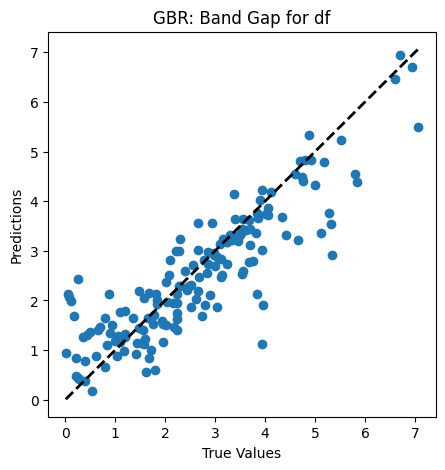

--------------------------------------------
--------------------------------------------
For dataframe: df_soap
GBR Model| R2 sq on train set: 0.9180
GBR Model| R2 sq on test set: 0.8195
GBR Model| MSE on test set: 0.4351
GBR Model| MAE on test set: 0.5032


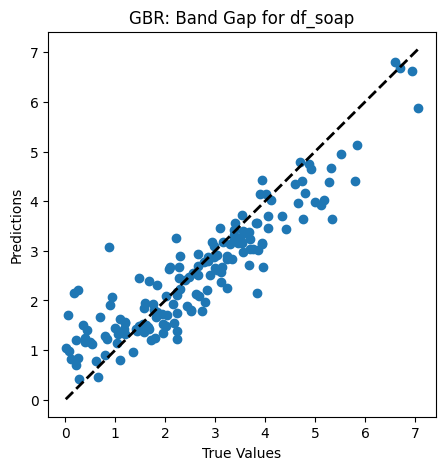

--------------------------------------------
--------------------------------------------
For dataframe: df_leadfree
GBR Model| R2 sq on train set: 0.9151
GBR Model| R2 sq on test set: 0.8076
GBR Model| MSE on test set: 0.5001
GBR Model| MAE on test set: 0.5320


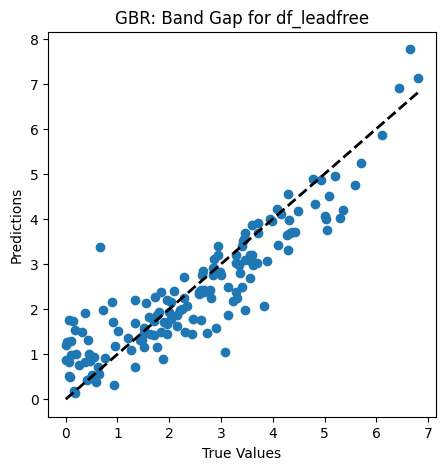

--------------------------------------------
--------------------------------------------
For dataframe: df_abundant
GBR Model| R2 sq on train set: 0.9784
GBR Model| R2 sq on test set: 0.7580
GBR Model| MSE on test set: 0.7606
GBR Model| MAE on test set: 0.5532


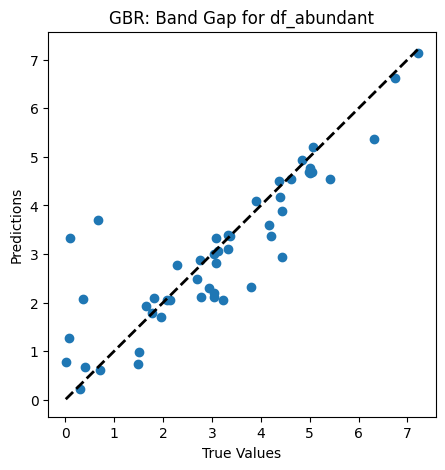

--------------------------------------------


In [ ]:
# Train and test the Gradient Boosting Regressor model for each DataFrame in the list_df_GBR
train_GBR(list_df_GBR[0], n_estimators=[200], learning_rate=[0.2], max_depth=[3])
train_GBR(list_df_GBR[1], n_estimators=[200], learning_rate=[0.1], max_depth=[3])
train_GBR(list_df_GBR[2], n_estimators=[200], learning_rate=[0.1], max_depth=[3])
train_GBR(list_df_GBR[3], n_estimators=[200], learning_rate=[0.1], max_depth=[3])

In [ ]:
# Evaluate the models for each DataFrame in the list_df_GBR
for df in list_df_GBR:
    print(f"Evaluating model for {df.name} with 5-fold cross-validation:")
    metrics = evaluate_model_with_cv(df.model, df, random_state=42)
    print("\n")  # Add a newline for better readability between different DataFrames

Evaluating model for df with 5-fold cross-validation:
Average RMSE: 0.5975 	 and std err: 0.0375
Average RMAE: 0.5359 	 and std err: 0.0115
Average R2_train: 0.9678 	 and std err: 0.0008
Average R2_test: 0.7606 	 and std err: 0.0167


Evaluating model for df_soap with 5-fold cross-validation:
Average RMSE: 0.5969 	 and std err: 0.0371
Average RMAE: 0.5641 	 and std err: 0.0115
Average R2_train: 0.9235 	 and std err: 0.0012
Average R2_test: 0.7605 	 and std err: 0.0185


Evaluating model for df_leadfree with 5-fold cross-validation:
Average RMSE: 0.6504 	 and std err: 0.0361
Average RMAE: 0.5786 	 and std err: 0.0105
Average R2_train: 0.9217 	 and std err: 0.0011
Average R2_test: 0.7491 	 and std err: 0.0091


Evaluating model for df_abundant with 5-fold cross-validation:
Average RMSE: 0.7496 	 and std err: 0.1036
Average RMAE: 0.5586 	 and std err: 0.0333
Average R2_train: 0.9827 	 and std err: 0.0012
Average R2_test: 0.7498 	 and std err: 0.0439


